# Resolution books: cluster sequence analysis and section boundary detection

Six inventory numbers from `NL-HaNA_1.01.02` (3771, 3772, 3773, 3821, 3822, 3823) are
books of resolutions of the Dutch States General.  Each inventory is a single bound volume
of two-page spreads; after splitting into individual pages, each page contains ~120 lines
of dense resolution text.

Ground truth on the exact section structure (which scans form which section) is available,
but we deliberately **do not use it here**.  Instead, we ask: can the sequence of layout
cluster labels reveal the section boundaries without any ground-truth supervision?

Expected structural signals:
* **Front matter**: the first few scans are covers, title pages, and tables of contents with
  very few or zero transcribed lines — these should form a distinct cluster.
* **Section separators**: a new section may start with a partial page (last few lines of a
  resolution at the top, then blank), or a dedicated title page with a decorative heading.
* **Running text**: the bulk of each inventory — densely filled recto and verso pages of
  resolutions — should cluster tightly.  Verso and recto may form separate clusters if
  their indentation/margin patterns differ systematically.
* **Back matter**: end-of-volume indices or blank pages.

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    compute_corpus_median_width, is_opening, get_opening_features, split_scan,
)
from archival_structures.analysis.page_layout_clustering import cluster_page_layouts
from archival_structures.analysis.boundary_detection import is_empty_page
from archival_structures.stream_analysis import (
    run_length_encode, merge_short_runs,
    find_frequent_ngrams, find_tandem_repeats,
    label_transition_matrix,
)

REPO_ROOT = Path('../../')
DATA_ROOT = REPO_ROOT / 'data'

## Load and split all six inventories

The gap heuristic (`is_opening` + `split_scan`) splits two-page spreads into
individual verso/recto pages.  The front-cover and back-cover scans (aspect < 1) are
left as single pages.

In [2]:
INV_NUMBERS = ['3771', '3772', '3773', '3821', '3822', '3823']
ARCHIVE = 'NL-HaNA_1.01.02'

CORPORA = {}

for inv in INV_NUMBERS:
    inv_id = f'{ARCHIVE}_{inv}'
    pxd = DATA_ROOT / f'PageXML/NL-HaNA/{ARCHIVE}/{inv_id}'
    xml_files = sorted(pxd.glob('*.xml'))
    scans = [pagexml_parser.parse_pagexml_file(str(p)) for p in xml_files]

    median_w = compute_corpus_median_width(scans)
    pages = []
    for scan in scans:
        if is_opening(scan, corpus_median_width=median_w):
            feat = get_opening_features(scan, corpus_median_width=median_w)
            verso, recto = split_scan(scan, feat.separation_point)
            pages += [verso, recto]
        else:
            pages.append(scan)

    n_empty = sum(1 for p in pages if is_empty_page(p))
    CORPORA[inv] = {
        'scans': scans,
        'pages': pages,
        'pxd': pxd,
        'inv_id': inv_id,
    }
    print(f'{inv_id}: {len(scans)} scans → {len(pages)} pages  ({n_empty} empty)')

NL-HaNA_1.01.02_3771: 579 scans → 1156 pages  (20 empty)


NL-HaNA_1.01.02_3772: 595 scans → 1188 pages  (17 empty)


NL-HaNA_1.01.02_3773: 608 scans → 1214 pages  (15 empty)


NL-HaNA_1.01.02_3821: 440 scans → 878 pages  (13 empty)


NL-HaNA_1.01.02_3822: 463 scans → 924 pages  (10 empty)


NL-HaNA_1.01.02_3823: 442 scans → 882 pages  (14 empty)


## Layout clustering per inventory

We cluster each inventory independently using `cluster_page_layouts` (grid-pattern TF-IDF
fingerprint, HDBSCAN).  Cluster labels are inventory-local: cluster 0 in one inventory is
not necessarily the same page type as cluster 0 in another.

In [3]:
for inv, info in CORPORA.items():
    print(f'Clustering {info["inv_id"]} ...')
    labels, clusterer = cluster_page_layouts(
        info['pages'], min_cluster_size=5, min_samples=2,
    )
    info['labels'] = labels.tolist()
    info['clusterer'] = clusterer
    dist = sorted(Counter(info['labels']).items())
    noise_frac = info['labels'].count(-1) / len(info['labels'])
    print(f'  clusters: {dist}  noise: {noise_frac:.1%}')

Clustering NL-HaNA_1.01.02_3771 ...
done setting base grid points
took 0.0 seconds (total: 0.0)


done setting line grid_points for 1156 docs, with 53 x and 78 y points
took 0.9 seconds (total: 0.9)


done computing patterns, 426 distinct patterns
took 4.6 seconds (total: 5.5)
done computing tf-idf of patterns
took 0.2 seconds (total: 5.7)


  clusters: [(-1, 154), (0, 984), (1, 18)]  noise: 13.3%
Clustering NL-HaNA_1.01.02_3772 ...
done setting base grid points
took 0.0 seconds (total: 0.0)


done setting line grid_points for 1188 docs, with 52 x and 79 y points
took 0.9 seconds (total: 0.9)


...

done computing patterns, 477 distinct patterns
took 3.7 seconds (total: 4.5)
done computing tf-idf of patterns
took 0.1 seconds (total: 4.6)


  clusters: [(-1, 115), (0, 5), (1, 144), (2, 8), (3, 652)]  noise: 12.4%
Clustering NL-HaNA_1.01.02_3823 ...
done setting base grid points
took 0.0 seconds (total: 0.0)


done setting line grid_points for 882 docs, with 52 x and 76 y points
took 0.6 seconds (total: 0.6)


done computing patterns, 482 distinct patterns
took 3.4 seconds (total: 4.1)
done computing tf-idf of patterns
took 0.1 seconds (total: 4.2)


  clusters: [(-1, 156), (0, 14), (1, 155), (2, 551), (3, 6)]  noise: 17.7%


## Sequence strip visualisation

Six horizontal strips, one per inventory.  Each cell = one page (after splitting);
colour = cluster label.  Grey = HDBSCAN noise.

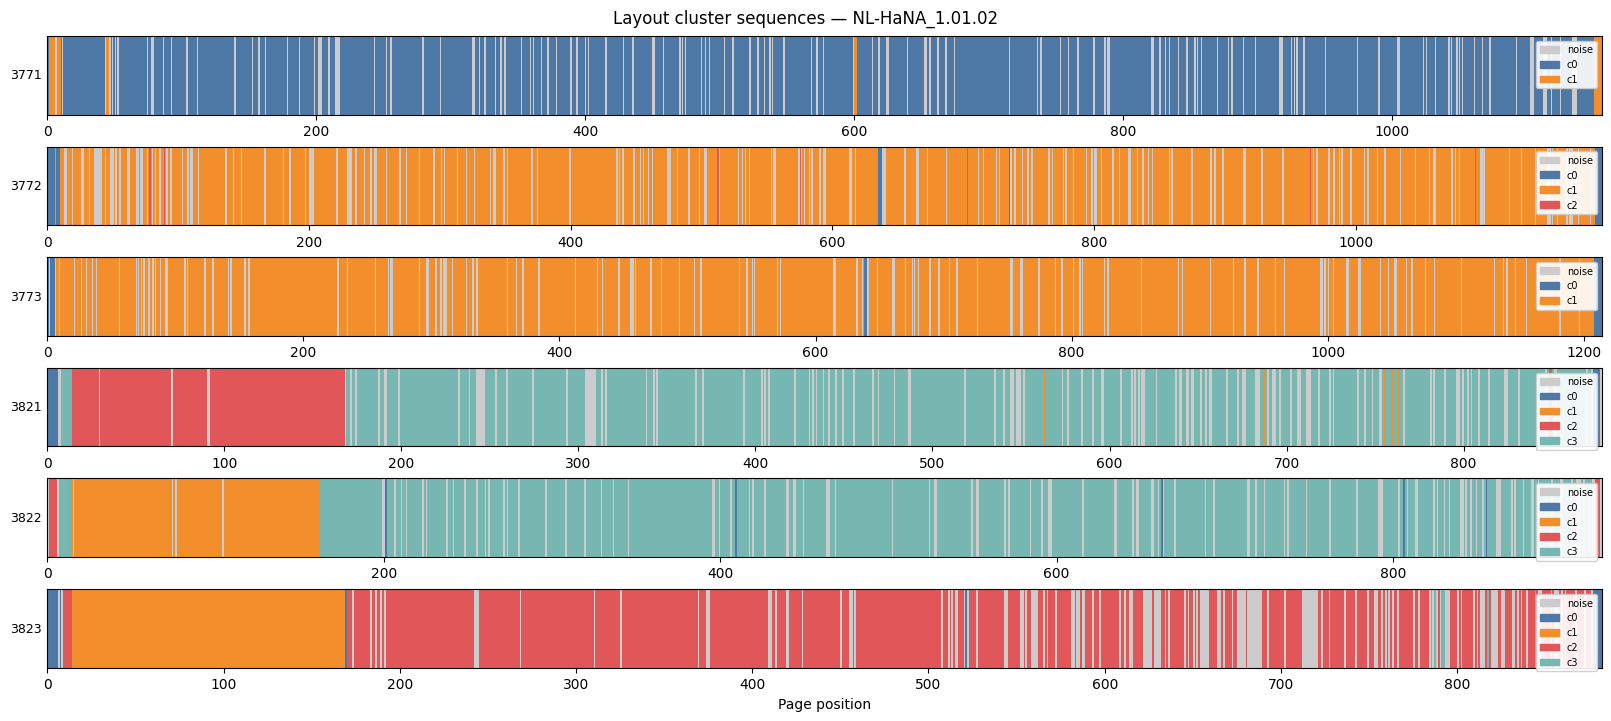

In [4]:
CLUSTER_COLORS = [
    '#4e79a7', '#f28e2b', '#e15759', '#76b7b2',
    '#59a14f', '#edc948', '#b07aa1', '#ff9da7',
    '#9c755f', '#bab0ac',
]
NOISE_COLOR = '#cccccc'

def cluster_color(label, noise_label=-1):
    if label == noise_label:
        return NOISE_COLOR
    return CLUSTER_COLORS[label % len(CLUSTER_COLORS)]


fig, axes = plt.subplots(len(CORPORA), 1, figsize=(16, len(CORPORA) * 1.1 + 0.5),
                         constrained_layout=True)
for ax, (inv, info) in zip(axes, CORPORA.items()):
    labels = info['labels']
    height = 0.6
    for i, lab in enumerate(labels):
        ax.add_patch(plt.Rectangle((i, 0), 1, height,
                                   color=cluster_color(lab), linewidth=0))
    ax.set_xlim(0, len(labels))
    ax.set_ylim(0, height)
    ax.set_yticks([])
    ax.set_ylabel(inv, fontsize=9, rotation=0, ha='right', va='center')
    # Legend
    unique = sorted(set(labels))
    patches = [
        mpatches.Patch(color=cluster_color(u),
                       label='noise' if u == -1 else f'c{u}')
        for u in unique
    ]
    ax.legend(handles=patches, loc='upper right', fontsize=7, framealpha=0.9)
ax.set_xlabel('Page position')
plt.suptitle(f'Layout cluster sequences — {ARCHIVE}', fontsize=12)
plt.show()

## Run-length analysis: long runs and sparse pages

After merging noise runs shorter than 5 pages into their neighbours, the dominant pattern
should be a single long run of the "running-text" cluster (the dense resolution pages)
interrupted by short runs of other types.

We look specifically at:
1. The front-matter region (first ~20 pages).
2. Runs of non-dominant clusters in the middle — these are the candidate section boundaries.
3. The back-matter region (last ~20 pages).

In [5]:
for inv, info in CORPORA.items():
    rle = run_length_encode(info['labels'])
    merged = merge_short_runs(rle, min_length=5)
    info['rle'] = rle
    info['rle_merged'] = merged

    # Find the dominant cluster
    c = Counter(info['labels'])
    c.pop(-1, None)
    dominant = c.most_common(1)[0][0] if c else -1
    info['dominant_cluster'] = dominant

    # Non-dominant runs in the interior (skip first / last 20 pages)
    n = len(info['pages'])
    interior_runs = [
        r for r in merged
        if r['cluster'] != dominant
        and r['cluster'] != -1
        and r['start'] > 20
        and r['end'] < n - 20
    ]
    info['interior_runs'] = interior_runs

    print(f'{info["inv_id"]}  ({len(info["pages"])} pages, dominant cluster={dominant})')
    print(f'  Non-dominant interior runs: {len(interior_runs)}')
    for r in interior_runs:
        mid_page = info['pages'][(r['start'] + r['end']) // 2]
        print(f'    c={r["cluster"]} len={r["length"]} pages [{r["start"]}–{r["end"]})')

NL-HaNA_1.01.02_3771  (1156 pages, dominant cluster=0)
  Non-dominant interior runs: 0
NL-HaNA_1.01.02_3772  (1188 pages, dominant cluster=1)
  Non-dominant interior runs: 0
NL-HaNA_1.01.02_3773  (1214 pages, dominant cluster=1)
  Non-dominant interior runs: 0
NL-HaNA_1.01.02_3821  (878 pages, dominant cluster=3)
  Non-dominant interior runs: 0
NL-HaNA_1.01.02_3822  (924 pages, dominant cluster=3)
  Non-dominant interior runs: 0
NL-HaNA_1.01.02_3823  (882 pages, dominant cluster=2)
  Non-dominant interior runs: 0


## Candidate section boundaries

A run of a non-dominant cluster in the interior of the book is a candidate boundary
between sections.  The position (as a fraction of total pages) can be compared against
the ground-truth section structure.

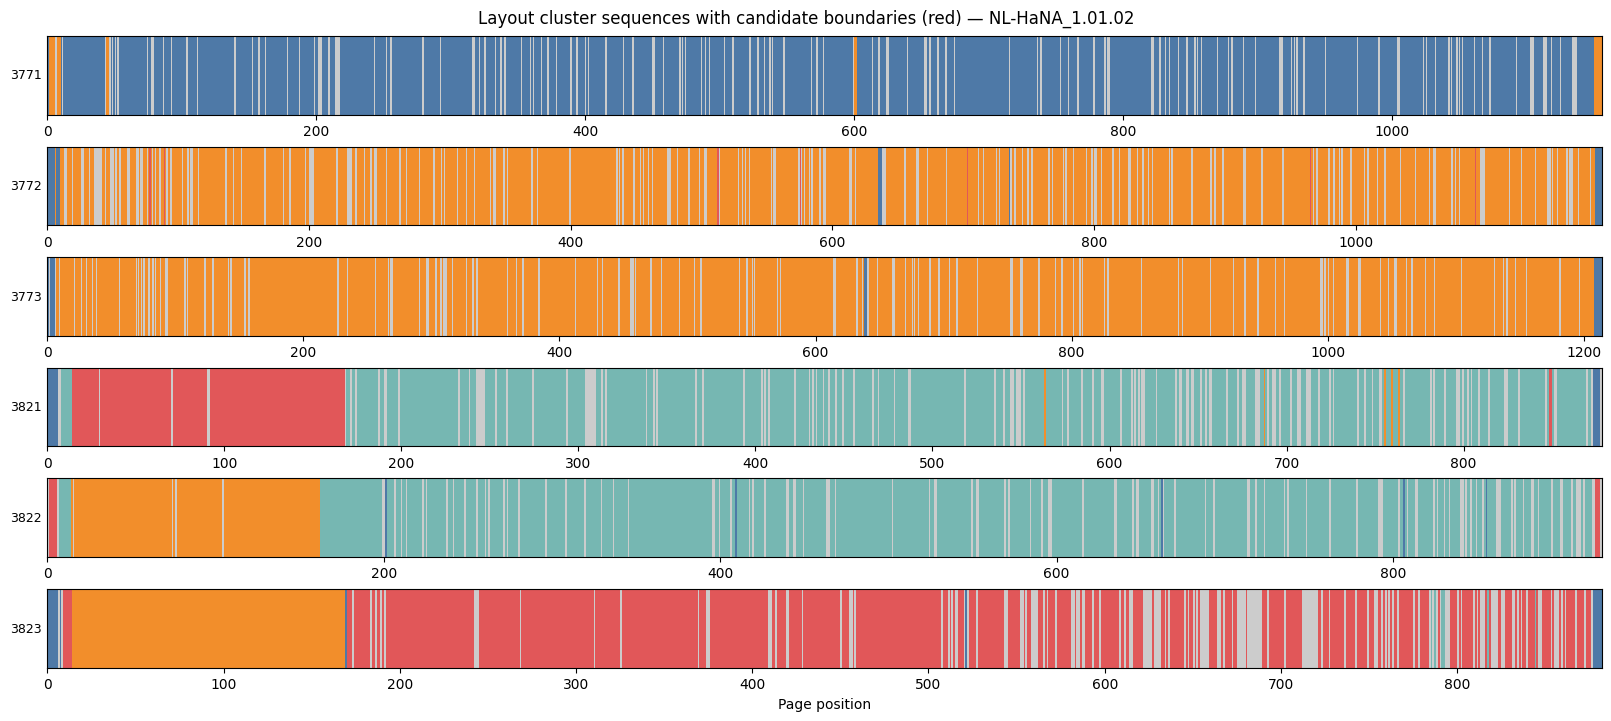

In [6]:
fig, axes = plt.subplots(len(CORPORA), 1, figsize=(16, len(CORPORA) * 1.1 + 0.5),
                         constrained_layout=True)

for ax, (inv, info) in zip(axes, CORPORA.items()):
    labels = info['labels']
    n = len(labels)
    height = 0.6
    for i, lab in enumerate(labels):
        ax.add_patch(plt.Rectangle((i, 0), 1, height,
                                   color=cluster_color(lab), linewidth=0))
    # Mark interior non-dominant runs with a vertical red line at midpoint
    for r in info['interior_runs']:
        mid = (r['start'] + r['end']) / 2
        ax.axvline(mid, color='red', linewidth=1.5, alpha=0.7)
        ax.text(mid, height * 0.5, f'  c{r["cluster"]}\n  ×{r["length"]}',
                fontsize=6, color='red', va='center')
    ax.set_xlim(0, n)
    ax.set_ylim(0, height)
    ax.set_yticks([])
    ax.set_ylabel(inv, fontsize=9, rotation=0, ha='right', va='center')

ax.set_xlabel('Page position')
plt.suptitle(f'Layout cluster sequences with candidate boundaries (red) — {ARCHIVE}', fontsize=12)
plt.show()

## Sparse page detection: scans with very few transcribed lines

Section title pages are often the sparsest pages in the inventory: they carry a decorative
heading and little else.  Plotting the line-count profile alongside the cluster-sequence
helps verify that the candidate boundaries above coincide with sparse pages.

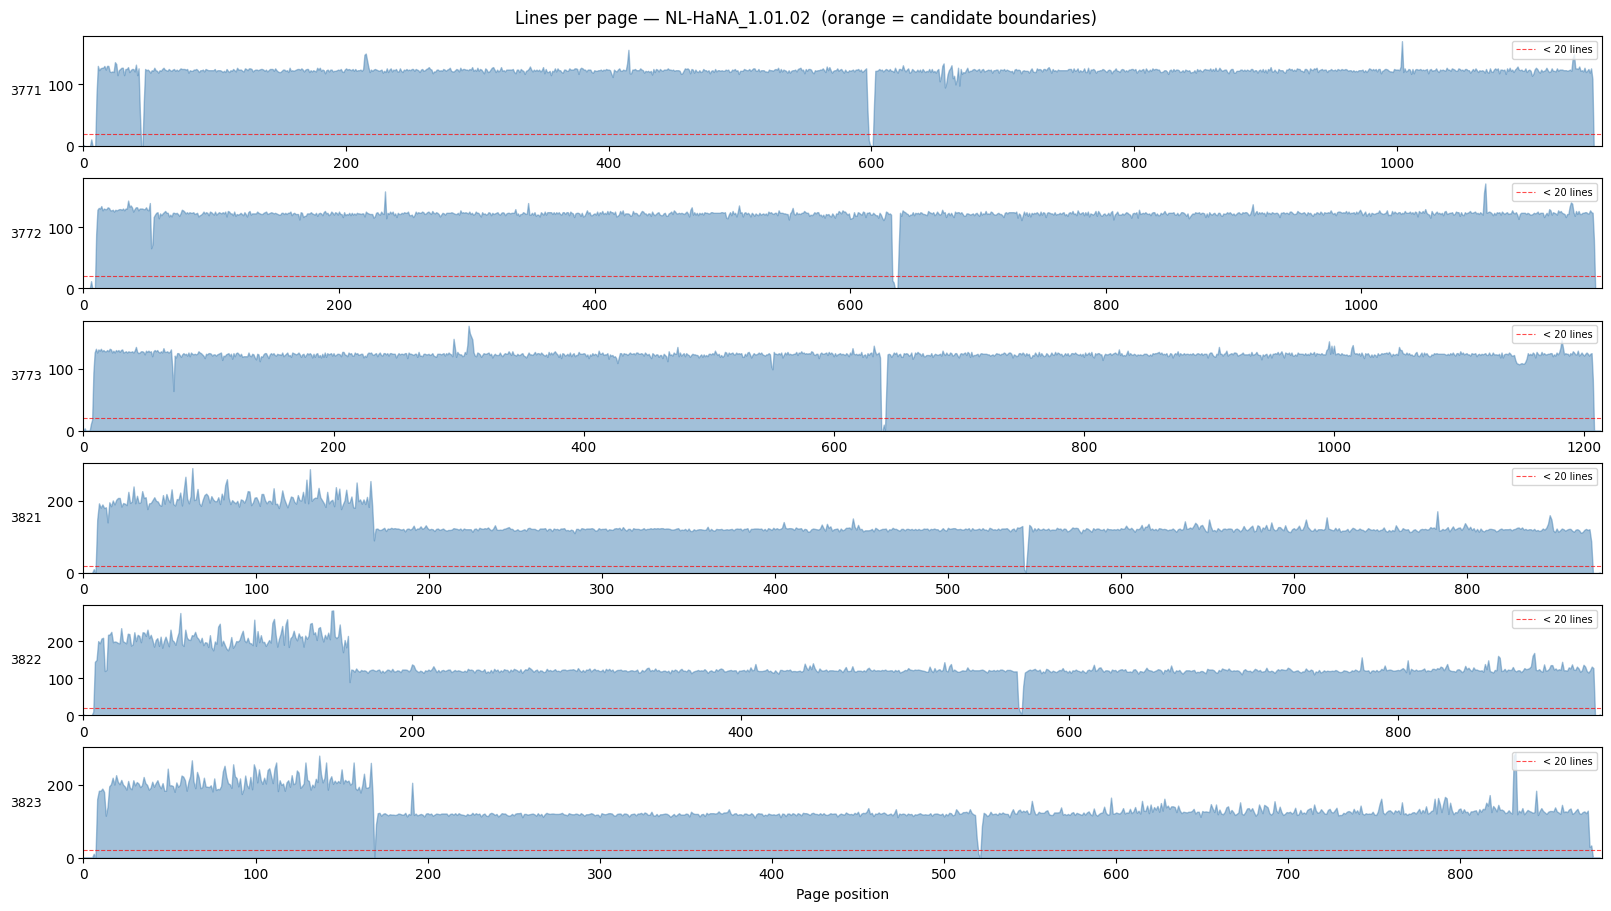

In [7]:
for inv, info in CORPORA.items():
    n_lines = [len(p.get_lines()) for p in info['pages']]
    info['n_lines'] = n_lines

fig, axes = plt.subplots(len(CORPORA), 1, figsize=(16, len(CORPORA) * 1.5),
                         constrained_layout=True)

for ax, (inv, info) in zip(axes, CORPORA.items()):
    positions = range(len(info['n_lines']))
    ax.fill_between(positions, info['n_lines'], alpha=0.5, color='steelblue')
    ax.axhline(20, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='< 20 lines')
    # Mark interior non-dominant runs
    for r in info['interior_runs']:
        ax.axvspan(r['start'], r['end'], color='orange', alpha=0.3)
    ax.set_xlim(0, len(info['n_lines']))
    ax.set_ylabel(inv, fontsize=9, rotation=0, ha='right', va='center')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=7, loc='upper right')

ax.set_xlabel('Page position')
plt.suptitle(f'Lines per page — {ARCHIVE}  (orange = candidate boundaries)', fontsize=12)
plt.show()

## N-gram patterns across inventories

For each inventory, the most frequent 2-grams and 3-grams in the (merged) label sequence
reveal the typical page-type transitions.  Across inventories from the same archive, the
same n-grams should dominate — confirming that the volumes follow a consistent structure.

In [8]:
for inv, info in CORPORA.items():
    # Expand merged RLE back to label list for n-gram analysis
    merged_labels = []
    for r in info['rle_merged']:
        merged_labels.extend([r['cluster']] * r['length'])
    info['merged_labels'] = merged_labels

    ngrams = find_frequent_ngrams(merged_labels, n=(2, 3), min_count=3)
    print(f'{info["inv_id"]} — top n-grams:')
    print(ngrams[['ngram', 'n', 'count']].head(10).to_string(index=False))
    print()

NL-HaNA_1.01.02_3771 — top n-grams:
    ngram  n  count
   (0, 0)  2   1142
(0, 0, 0)  3   1141
   (1, 1)  2     11
(1, 1, 1)  3      9

NL-HaNA_1.01.02_3772 — top n-grams:
    ngram  n  count
   (1, 1)  2   1158
(1, 1, 1)  3   1156
   (0, 0)  2     10
(0, 0, 0)  3      8

NL-HaNA_1.01.02_3773 — top n-grams:
    ngram  n  count
   (1, 1)  2   1207
(1, 1, 1)  3   1206
   (0, 0)  2      5
(0, 0, 0)  3      4

NL-HaNA_1.01.02_3821 — top n-grams:
    ngram  n  count
   (3, 3)  2    694
(3, 3, 3)  3    690
   (2, 2)  2    156
(2, 2, 2)  3    155
   (0, 0)  2      5
(0, 0, 0)  3      4

NL-HaNA_1.01.02_3822 — top n-grams:
    ngram  n  count
   (3, 3)  2    768
(3, 3, 3)  3    766
   (1, 1)  2    147
(1, 1, 1)  3    146
   (2, 2)  2      5
(2, 2, 2)  3      4

NL-HaNA_1.01.02_3823 — top n-grams:
    ngram  n  count
   (2, 2)  2    669
(2, 2, 2)  3    663
   (1, 1)  2    155
(1, 1, 1)  3    154
   (0, 0)  2     10
(0, 0, 0)  3      8



## Tandem repeats: the repeating unit structure

If sections follow a fixed template (e.g., every section ends with the same recto-verso
layout pair), tandem repeats of short n-grams should be present throughout the book.

In [9]:
for inv, info in CORPORA.items():
    tr = find_tandem_repeats(
        info['merged_labels'],
        min_unit=1, max_unit=4, min_repeats=4,
    )
    print(f'{info["inv_id"]} — tandem repeats (≥4 reps):')
    if len(tr) > 0:
        # Summarise: for each unit, total occurrences and typical span
        summary = (
            tr.groupby('unit')
              .agg(n_occurrences=('start', 'count'),
                   max_reps=('n_repeats', 'max'),
                   total_pages=('total_length', 'sum'))
              .sort_values('n_occurrences', ascending=False)
        )
        print(summary.head(8).to_string())
    else:
        print('  (none with ≥4 repetitions)')
    print()

NL-HaNA_1.01.02_3771 — tandem repeats (≥4 reps):
              n_occurrences  max_reps  total_pages
unit                                              
(1,)                      2         7           13
(0,)                      1      1143         1143
(0, 0)                    1       571         1142
(0, 0, 0)                 1       381         1143
(0, 0, 0, 0)              1       285         1140

NL-HaNA_1.01.02_3772 — tandem repeats (≥4 reps):
              n_occurrences  max_reps  total_pages
unit                                              
(0,)                      2         7           12
(1,)                      2      1135         1160
(1, 1)                    2       567         1158
(1, 1, 1)                 2       378         1158
(1, 1, 1, 1)              2       283         1156

NL-HaNA_1.01.02_3773 — tandem repeats (≥4 reps):
              n_occurrences  max_reps  total_pages
unit                                              
(0,)                      1        

## Transition matrix: which cluster follows which?

A heatmap of transition probabilities makes the cluster grammar visible:
a cluster that is always followed by itself is a long homogeneous run;
a cluster that is always followed by a specific other cluster is a structural connector.

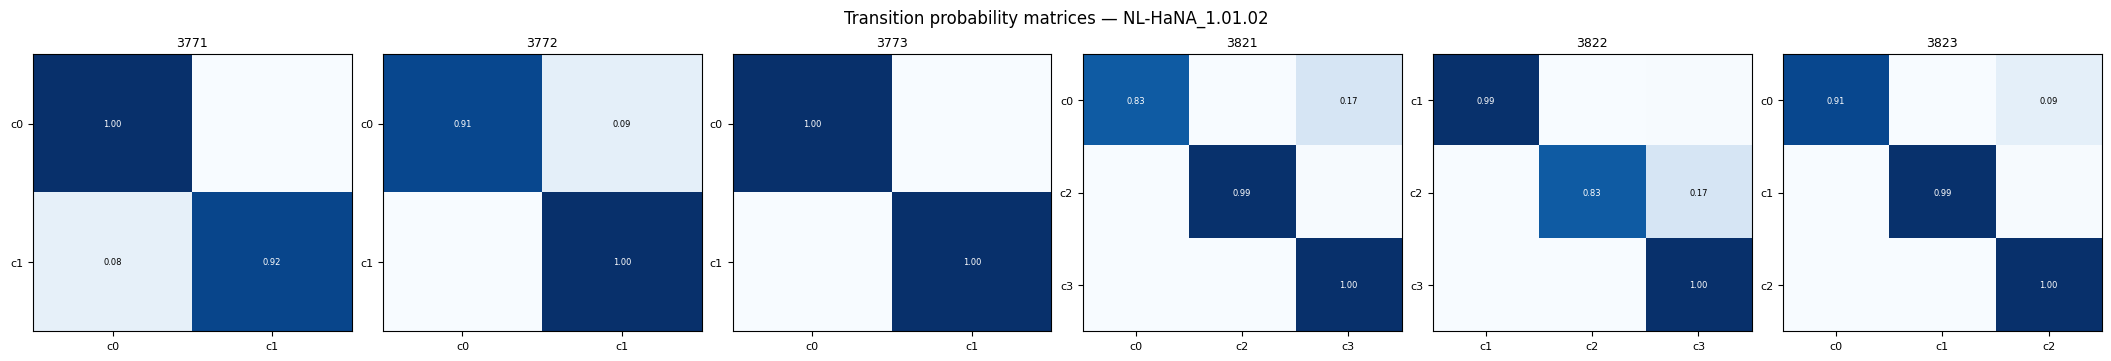

In [10]:
n_inv = len(CORPORA)
fig, axes = plt.subplots(1, n_inv, figsize=(3.5 * n_inv, 3.5), constrained_layout=True)

for ax, (inv, info) in zip(axes, CORPORA.items()):
    tm = label_transition_matrix(info['merged_labels'], normalize=True)
    im = ax.imshow(tm.values, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(tm.columns)))
    ax.set_yticks(range(len(tm.index)))
    ax.set_xticklabels([f'c{c}' if c >= 0 else 'noise' for c in tm.columns], fontsize=8)
    ax.set_yticklabels([f'c{c}' if c >= 0 else 'noise' for c in tm.index], fontsize=8)
    ax.set_title(inv, fontsize=9)
    for i in range(len(tm.index)):
        for j in range(len(tm.columns)):
            v = tm.values[i, j]
            if v > 0.05:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=6, color='white' if v > 0.6 else 'black')

plt.suptitle(f'Transition probability matrices — {ARCHIVE}', fontsize=12)
plt.show()

## Summary

The cluster sequence analysis of the six resolution-book inventories reveals:

1. **A dominant cluster** corresponding to the dense running-text pages of resolutions,
   which self-transitions at high probability (confirms long homogeneous runs).
2. **A small number of candidate section boundaries**: interior runs of non-dominant
   clusters that coincide with the sparse pages in the line-count profile.
3. **Consistent recto/verso alternation** (if separate clusters form for even/odd pages,
   the 2-gram of those two clusters is the most frequent n-gram).
4. **Cross-inventory consistency**: the same cluster types and n-gram patterns appear
   across all six inventories, reflecting the uniform format of the resolution books.

The next step is to compare the candidate boundary positions against the known ground-truth
section metadata to quantify how well the unsupervised cluster sequence recovers the
actual section structure.